# 实例：基于随机森林模型的红酒品质分析

## 1.调用库，导入数据

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore') 

try:
    wine = pd.read_csv('c:/dataset/winequality-red.csv',sep = ';') 
except:
    print("Cannot find the file!")

wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


## 2.数据探索

### 2.1 检查数据错误（缺失值、重复值和异常值处理，跟数据预处理工作有重叠）

In [2]:
#看数据的基本情况，一共有1599条非空数据，有12个属性
wine.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [3]:
##检查是否有重复记录，有的话是True，没有是False
print(wine.duplicated()) 
#sum显示有多少条重复记录
print(wine.duplicated().sum()) 

#删除重复记录
wine= wine.drop_duplicates()
wine

0       False
1       False
2       False
3       False
4        True
        ...  
1594    False
1595    False
1596     True
1597    False
1598    False
Length: 1599, dtype: bool
240


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### 2.2 基本数据特征分析

### 2.2.1 分布分析（定量和定性）

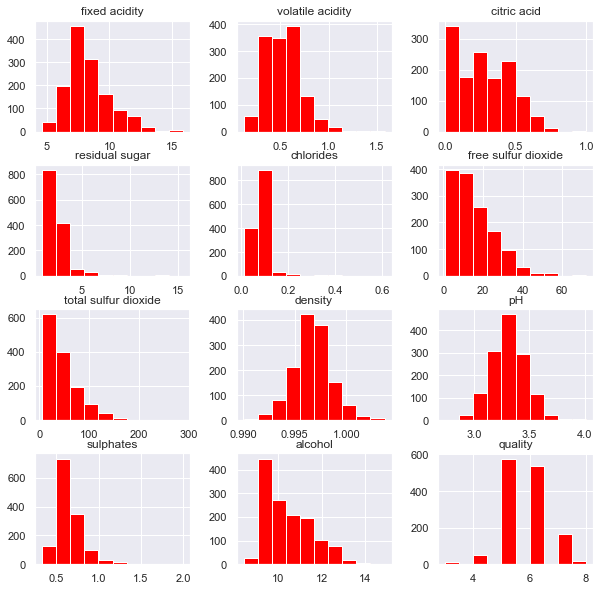

In [4]:
import seaborn as sns
#设置了Seaborn的默认图表风格。这个函数可以接收多个参数来自定义图表的外观，例如颜色主题、字体大小等。
sns.set()

#使用Seaborn的hist函数绘制了wine12个属性列的直方图。定量的分布分析
wine.hist(figsize=(10,10), color='red');


### 12个属性列，只有目标属性列是离散型变量，其评价范围是0-10，数据集中范围是3到8，有82%的红酒品质是5或6。

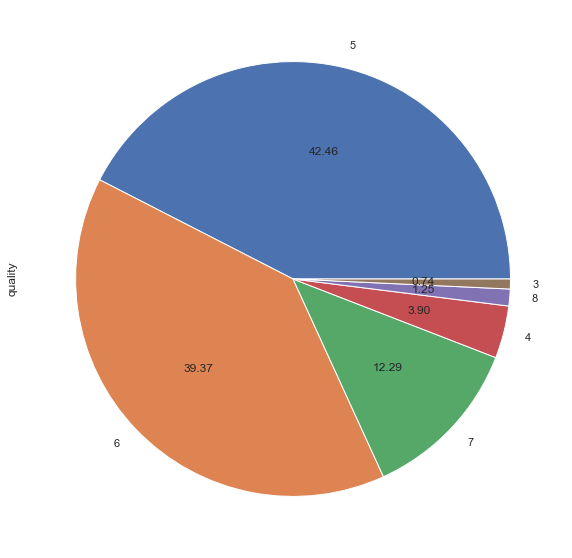

In [5]:
#分布分析（定性分析饼状图）
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(15, 10))
wine['quality'].value_counts().plot(kind = 'pie', autopct = '%.2f',ax=ax);

### 2.2.2 统计量分析

In [6]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


### 2.2.3 相关分析（看quality与其他属性的相关性）

In [7]:
wine.corr().quality

fixed acidity           0.119024
volatile acidity       -0.395214
citric acid             0.228057
residual sugar          0.013640
chlorides              -0.130988
free sulfur dioxide    -0.050463
total sulfur dioxide   -0.177855
density                -0.184252
pH                     -0.055245
sulphates               0.248835
alcohol                 0.480343
quality                 1.000000
Name: quality, dtype: float64

### 可以看出volatile acidity和alcohol的指数接近0.5，是相对较高的。

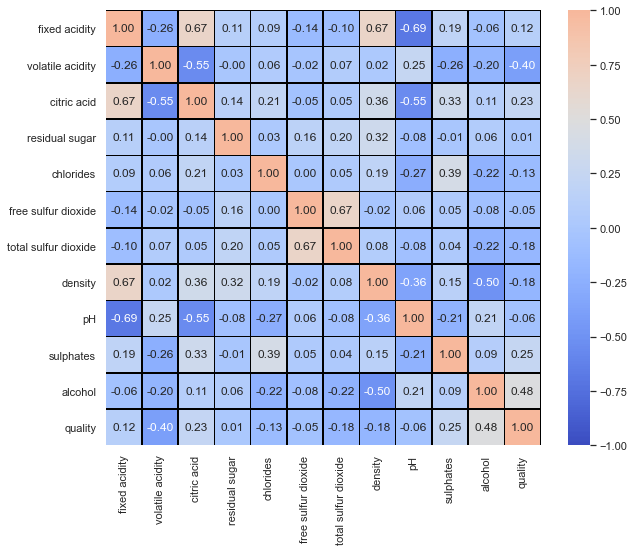

In [8]:
#绘制相关系数矩阵热力图
corr_matrix = wine.corr()  # 计算相关系数矩阵
plt.figure(figsize=(10, 8))  # 设置图形大小
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', square=True, center=0.5, fmt='.2f',linewidth=0.5,linecolor='black', vmin=-1, vmax=1, xticklabels=True, yticklabels=True,cbar=True);


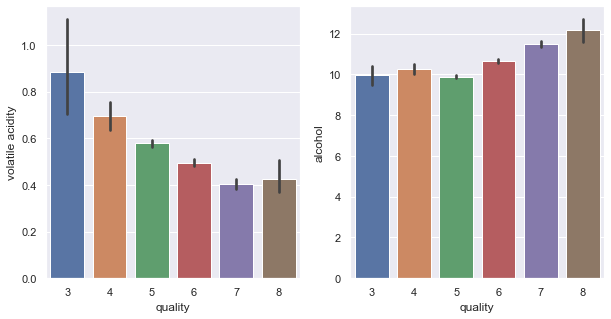

In [9]:
# 相关分析可视化
plt.figure(figsize=(10, 5))  # 设置画布大小
plt.subplot(121)
sns.barplot(x = 'quality', y = 'volatile acidity', data = wine)
plt.subplot(122)
sns.barplot(x = 'quality', y = 'alcohol', data = wine)
plt.show()

### 可以看出volarile acidity挥发性酸度越低，quality越高；alcohol乙醇越高，quality越高。

## 3.数据预处理：数据变换  将quality原6个等级转换成3个

In [10]:
bins = (2, 4, 6, 8)
group_names  = ['low', 'medium', 'high']
wine['quality_lb'] = pd.cut(wine['quality'], bins = bins, labels = group_names)

from sklearn.preprocessing import LabelEncoder
lb_quality = LabelEncoder()    
wine['label'] = lb_quality.fit_transform(wine['quality_lb']) 
wine.head(10)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_lb,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,medium,2
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,medium,2
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,medium,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,medium,2
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,medium,2
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,medium,2
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,high,0
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,high,0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,medium,2
10,6.7,0.58,0.08,1.8,0.097,15.0,65.0,0.9959,3.28,0.54,9.2,5,medium,2


In [11]:
#统计新类别的分类
wine.label.value_counts()

2    1112
0     184
1      63
Name: label, dtype: int64

### 可以看到1表示low，2表示medium，0表示high

In [12]:
#常用于保留原始数据集的一个副本，以便在进行数据清洗或特征工程时不会影响原始数据。
wine_copy = wine.copy()

#删除了名为 'quality' 和 'quality_lb' 的列。处理成12列：11个特征属性和label列
wine.drop(['quality', 'quality_lb'], axis = 1, inplace = True) 
wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,2
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,2
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,2
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,2
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,2
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,2
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,2


In [13]:
#把11个特征属性，存入x，label为目标属性，存入y
X = wine.iloc[:,:-1]
y = wine.label

## 4.数据挖掘建模：随机森林模型进行分类预测

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import scale
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix


#1.数据准备： 使用 train_test_split 将数据集 X 和目标变量 y 分成训练集和测试集，测试集占数据的20%,设置随机状态为 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#数据预处理： 使用 scale 函数对训练集 X_train 和测试集 X_test 进行标准化处理
X_train = scale(X_train)
X_test = scale(X_test)

#2.设置模型参数： 
#创建 RandomForestClassifier 的实例，设置 n_estimators 树的数量参数为100
rfc = RandomForestClassifier(n_estimators=100,random_state=42)

#3.模型训练：使用训练集 X_train 和目标变量 y_train 训练随机森林模型。
rfc.fit(X_train, y_train)

# 4.预测结果：使用训练好的模型对测试集 X_test 进行预测，得到预测结果 y_pred。
y_pred = rfc.predict(X_test)

# 5.评估初始模型
print("初始模型的混淆矩阵：")
print(confusion_matrix(y_test, y_pred))

#6.参数调优：定义了参数网格 param_rfc
param_rfc = {
    'n_estimators': [100, 200],
    'criterion': ['gini', 'entropy'],  #分裂标准
    'max_depth': [None, 10, 20],   #树的最大深度
    'min_samples_split': [2, 5]   #定义在树的每个节点上进行分裂所需的最小样本数量
}

# 创建 GridSearchCV 实例 grid_rfc
grid_rfc = GridSearchCV(rfc, param_rfc, iid=False, cv=5)

#7.训练与获取最佳参数：使用 fit 方法在训练集 X_train 和 y_train 上训练 grid_rfc。
grid_rfc.fit(X_train, y_train)

#通过调用 grid_rfc.best_estimator_ 获取使用最佳参数训练的模型。
best_rfc = grid_rfc.best_estimator_
print("使用最佳参数的模型：")
print(best_rfc)

#8.使用最佳模型重新预测
y_pred = best_rfc.predict(X_test)

#9.评估模型：
print("最佳参数模型的混淆矩阵：")
print(confusion_matrix(y_test, y_pred))

初始模型的混淆矩阵：
[[ 14   0  20]
 [  0   0  15]
 [  6   0 217]]
使用最佳参数的模型：
RandomForestClassifier(criterion='entropy', n_estimators=200, random_state=42)
最佳参数模型的混淆矩阵：
[[ 15   0  19]
 [  0   0  15]
 [  5   0 218]]


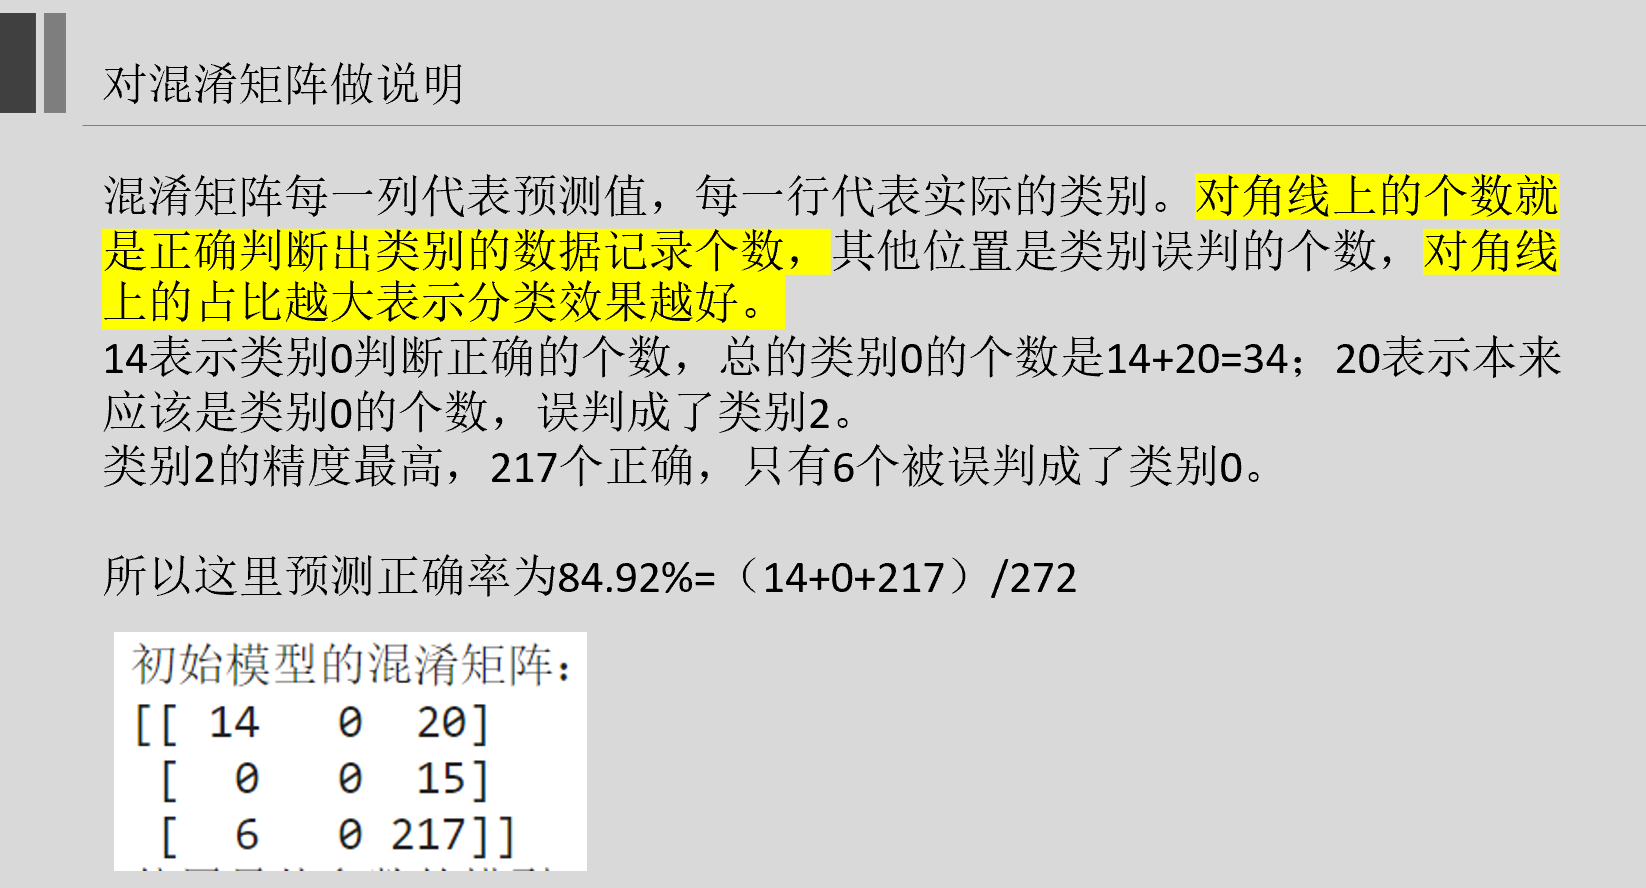

## 5.模型部署： 使用模型预测
将训练好的模型部署到生产环境中，用于实时预测红酒品质。

In [15]:
# 定义一个新的数据点 x1，并使用训练好的模型进行预测。
x1= [[7.4, 0.7,0,1.9,0.076,11,34,0.9978,3.51,0.56,9.4]]
y1= rfc.predict(x1) #使用模型做出预测
print(y1)

[2]


In [16]:
x4= [wine.iloc[6,0:11].tolist()]
y4= rfc.predict(x4) #使用模型做出预测
print(y4) 

[2]


In [17]:
 wine.iloc[6].tolist()

[7.3, 0.65, 0.0, 1.2, 0.065, 15.0, 21.0, 0.9946, 3.39, 0.47, 10.0, 0.0]